# 0. Load Data

## 0.1 Load Data

In [98]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..", "outputs", "run-25-05-01-01")  # doid - no controls
# run_dir = os.path.join("..", "outputs", "run-25-05-07-01")  # doid - grouped diseases
run_dir = os.path.join("..", "outputs", "run-25-07-08-07")  # doid - grouped diseases - ECS
# run_dir = os.path.join("..", "outputs", "run-25-07-09-05")  # doid - grouped diseases - DAB
# run_dir = os.path.join("..", "outputs", "run-25-05-07-02")  # doid - control + dataset
run_dir = os.path.join("..","outputs","run-25-07-24-02")
run_dir = os.path.join("..","outputs","run-25-07-26-01")
run_dir = os.path.join("..","outputs","run-25-08-04-08") # doid - grouped multilabel lvl1
run_dir = os.path.join("..","outputs","run-25-08-05-01") # doid - grouped multilabel bot 50
run_dir = os.path.join("..","..","outputs","run-25-08-08-02") # doid - grouped multilabel CLS
run_dir = os.path.join("..","..","outputs","run-25-08-08-03") # doid - grouped multilabel CLS_MULTILABEL
run_dir = os.path.join("..","..","outputs","run-25-08-18-03") # doid - RNA-seq multilabel top 50 CLS_MULTILABEL
run_dir = os.path.join("..","..","outputs","run-25-08-19-01") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL
run_dir = os.path.join("..","..","outputs","run-25-08-20-01") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL
run_dir = os.path.join("..","..","outputs","run-25-08-21-01") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL + NEW LOSS
run_dir = os.path.join("..","..","outputs","run-25-08-21-02") # doid - RNA-seq multilabel top 50 CLS_MULTILABEL + CONTROL + NEW LOSS
# run_dir = os.path.join("..","..","outputs","run-25-08-21-03") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL + NEW LOSS x 5 times effect
run_dir = os.path.join("..","..","outputs","run-25-08-22-06") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL + NEW LOSS + COMBAT
run_dir = os.path.join("..","..","outputs","run-25-08-23-02") # doid - RNA-seq multilabel lvl50 CLS_MULTILABEL + CONTROL + 0.2 NEW LOSS + COMBAT

output_dir = os.path.join(run_dir, "outputs")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions



# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: random
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do


In [2]:
import importlib

importlib.reload(ut)
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

## Quality Control

In [3]:
epoch_loss = pickle.load(open(os.path.join(run_dir, "metrics_epochs.pkl"), "rb"))

In [4]:
epoch_loss.keys()

dict_keys(['split_1'])

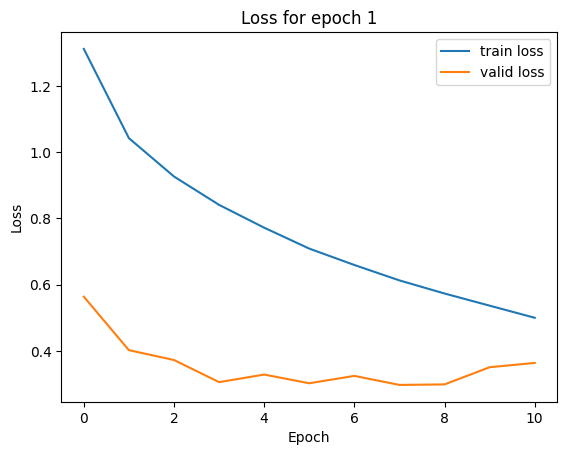

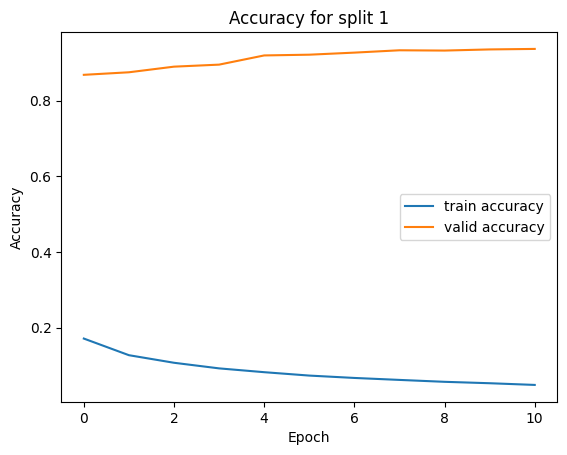

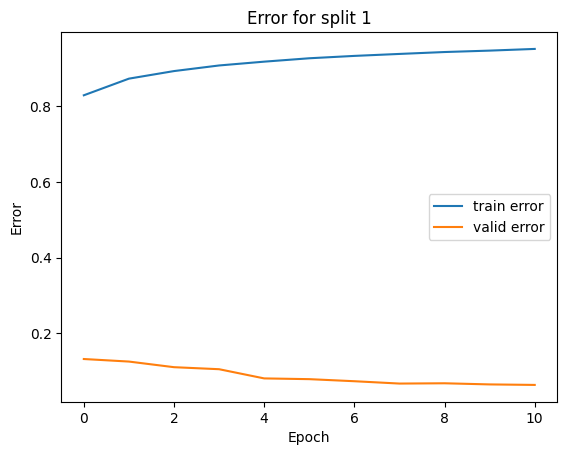

In [5]:
def plot_loss(epoch_loss: dict, split: int = 2):
    t_loss = epoch_loss[f"split_{split}"]["train_loss"]
    v_loss = epoch_loss[f"split_{split}"]["valid_loss"]
    plt.plot(t_loss, label="train loss")
    plt.plot(v_loss, label="valid loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss for epoch {split}")
    plt.legend()
    plt.show()

plot_loss(epoch_loss, split=1)


def plot_accuracy(epoch_loss: dict, split: int = 2):
    t_acc = epoch_loss[f"split_{split}"]["train_acc"]
    v_acc = epoch_loss[f"split_{split}"]["valid_acc"]
    plt.plot(t_acc, label="train accuracy")
    plt.plot(v_acc, label="valid accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy for split {split}")
    plt.legend()
    plt.show()

plot_accuracy(epoch_loss, split=1)


def plto_err(epoch_loss: dict, split: int = 2):
    t_err = epoch_loss[f"split_{split}"]["train_err"]
    v_err = epoch_loss[f"split_{split}"]["valid_err"]
    plt.plot(t_err, label="train error")
    plt.plot(v_err, label="valid error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.title(f"Error for split {split}")
    plt.legend()
    plt.show()
    
plto_err(epoch_loss, split=1)

In [6]:
data = list()

for i in range(0, len(results_test)):
    data.append(
        {
            "accuracy": results_test[i]["test/accuracy"],
            "precision": results_test[i]["test/precision"],
            "recall": results_test[i]["test/recall"],
            "macro_f1": results_test[i]["test/macro_f1"],
            "type": "test",
        }
    )
    data.append(
        {
            "accuracy": results_valid[i]["test/accuracy"],
            "precision": results_valid[i]["test/precision"],
            "recall": results_valid[i]["test/recall"],
            "macro_f1": results_valid[i]["test/macro_f1"],
            "type": "validation",
        }
    )
    data.append(
        {
            "accuracy": results_train[i]["test/accuracy"],
            "precision": results_train[i]["test/precision"],
            "recall": results_train[i]["test/recall"],
            "macro_f1": results_train[i]["test/macro_f1"],
            "type": "train",
        }
    )

df_performance = pd.DataFrame(data)

if len(results_test) == 1:
    # Grouping the dataframe by 'Type' and computing the mean for each metric
    df_grouped_mean = df_performance.groupby("type").mean()

    # Computing the standard deviation for each metric
    df_grouped_std = df_performance.groupby("type").std()

    # Merging the mean and std into a single dataframe with the format "mean ± std"
    df_performance_summary = df_grouped_mean.astype(str)

    # Formatting the mean and std to display only 3 decimal places
    df_performance_summary = df_grouped_mean.round(3).astype(str)


else:
    # Grouping the dataframe by 'Type' and computing the mean for each metric
    df_grouped_mean = df_performance.groupby("type").mean()

    # Computing the standard deviation for each metric
    df_grouped_std = df_performance.groupby("type").std()

    # Merging the mean and std into a single dataframe with the format "mean ± std"
    df_performance_summary = (
        df_grouped_mean.astype(str) + " ± " + df_grouped_std.astype(str)
    )

    # Formatting the mean and std to display only 3 decimal places
    df_performance_summary = (
        df_grouped_mean.round(3).astype(str) + " ± " + df_grouped_std.round(3).astype(str)
    )




df_performance_summary

,accuracy,precision,recall,macro_f1
type,,,,
test,0.44,0.312,0.394,0.337
train,0.658,0.591,0.949,0.71
validation,0.612,0.523,0.863,0.632


<Axes: ylabel='macro_f1'>

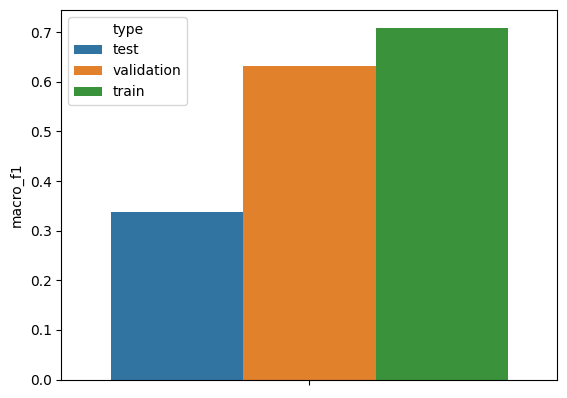

In [7]:
sns.barplot(data=df_performance, hue="type", y="macro_f1")



# 1. Load Data

## 1.1 Load scGPT Embeddings

In [99]:
"""Here we will evaluate the Embeddings
Analyze how well the embeddings capture same disease as well as related diseases
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable
split_idx = 0

# functions


In [100]:
# 2. Load Data
# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)

# load scGPT embeddings
embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])



# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "cosine")
c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "cosine")
c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "cosine")

## 1.2 Load DO pairs

In [10]:
"""1.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")



Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215


In [101]:

# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

Nº of pairs in dataset: (8515, 8)
Nº of significant pairs in dataset (top 5% IC): (1015, 8)
Nº of significant pairs in dataset (top 1% IC): (382, 8)
Nº of negative pairs in dataset (outside 5%): (7500, 8)


# 2. Benchmark Disease vs Control Similarity

In [18]:
import importlib
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

In [ ]:
"""2. Benchmark Disease vs Control Similarity

Structure:
    1. Imports, Variables, Functions
    2. Get Similarity
    3. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
from tqdm import tqdm
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# variables


# functions
# 2. Get Similarity
(c_same_same, w_same_same), (c_same_diff, w_same_diff), (c_ctrl_same, w_ctrl_same), (c_ctrl_diff, w_ctrl_diff) = vz.get_same_disease_sim(adata_train.obs, c_matrix_train)

# get unrelated pairs
c_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=1000,
    seed=42,
)

Processing same disease pairs: 100%|██████████| 132/132 [00:12<00:00, 10.42it/s] 


132 diseases in dataset


8646it [00:25, 343.09it/s]


In [42]:
len(c_same_diff)

1459165

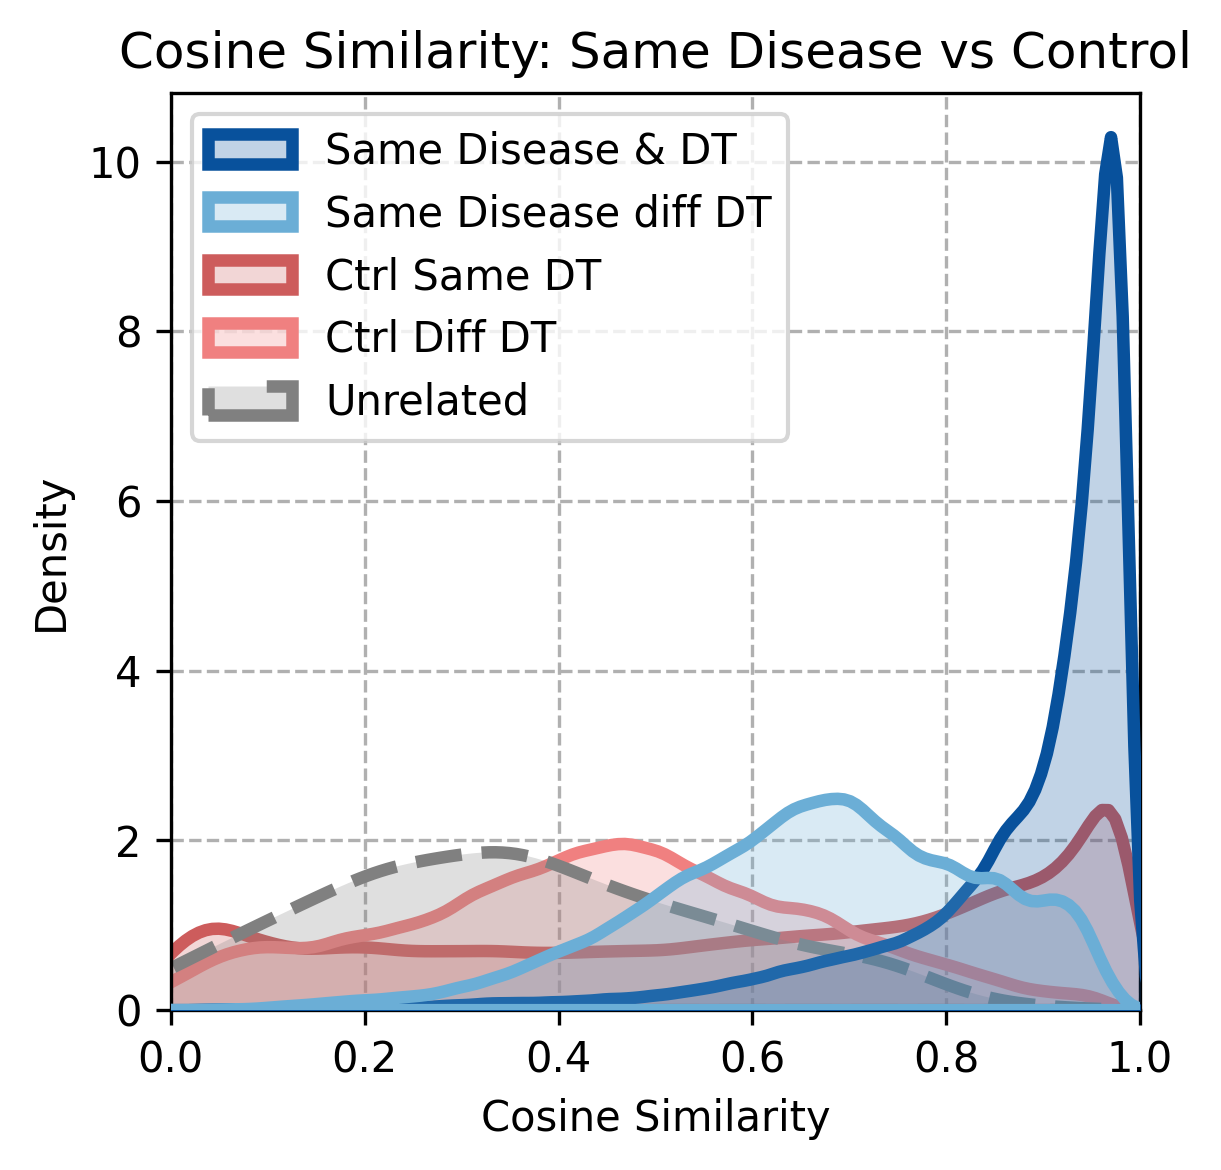

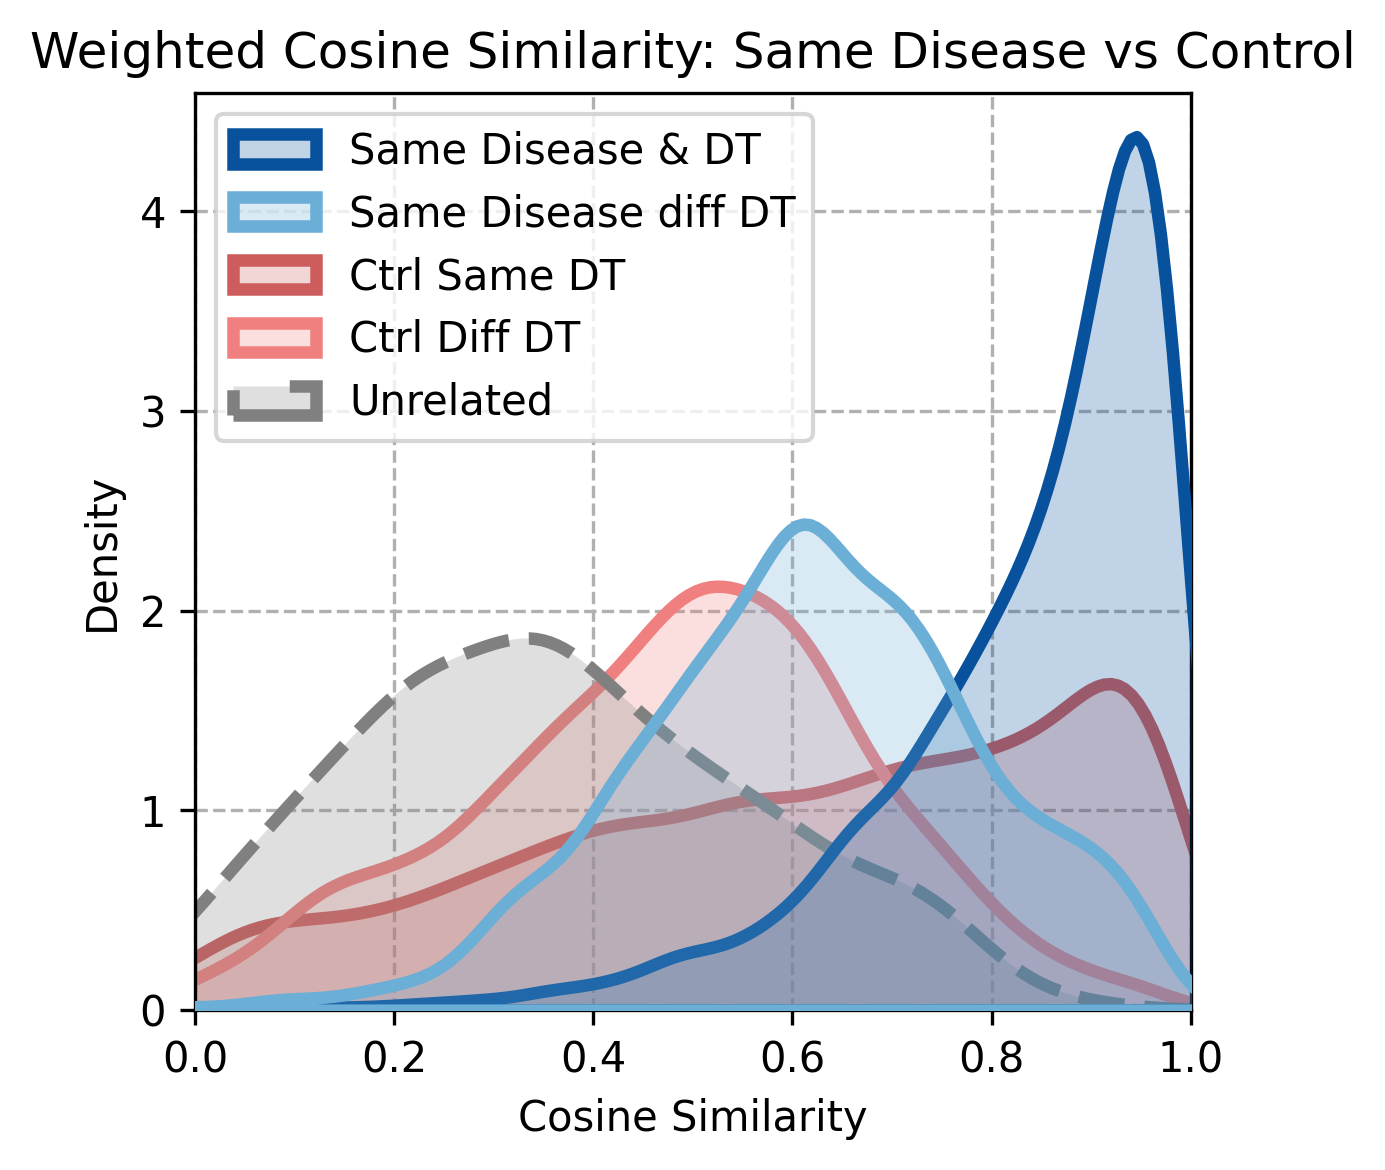

In [ ]:
# 3. Plot Similarity
# unweighted
vz.plot_kde([c_same_same, c_same_diff, c_ctrl_same, c_ctrl_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Cosine Similarity: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=None)

# weighted
vz.plot_kde([c_same_same, c_same_diff, c_ctrl_same, c_ctrl_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Weighted Cosine Similarity: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=[w_same_same, w_same_diff, w_ctrl_same, w_ctrl_diff, None])

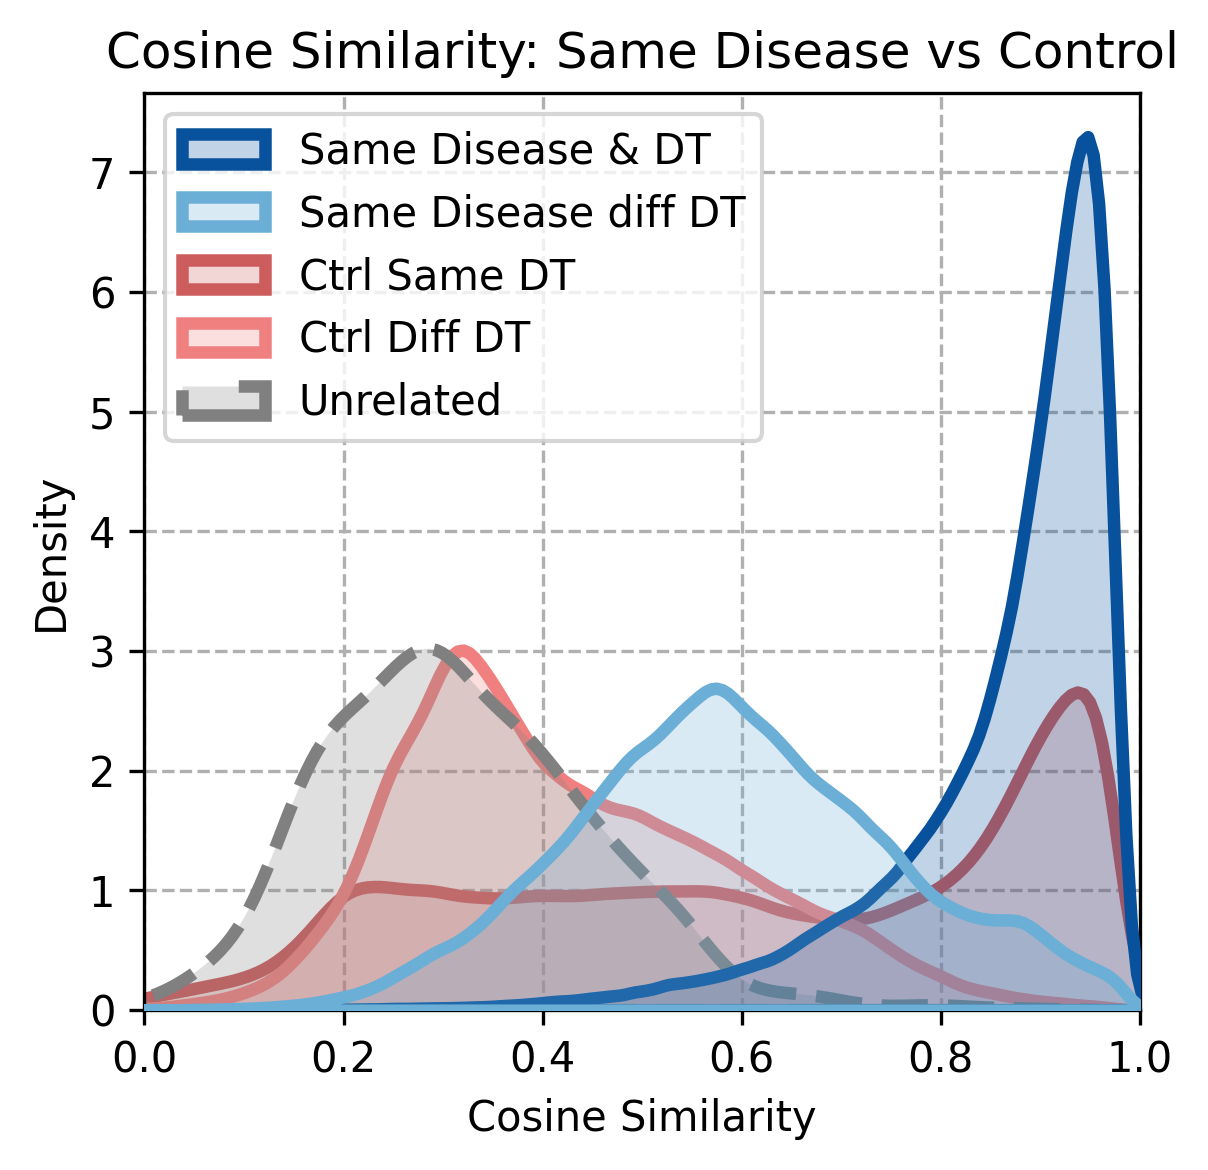

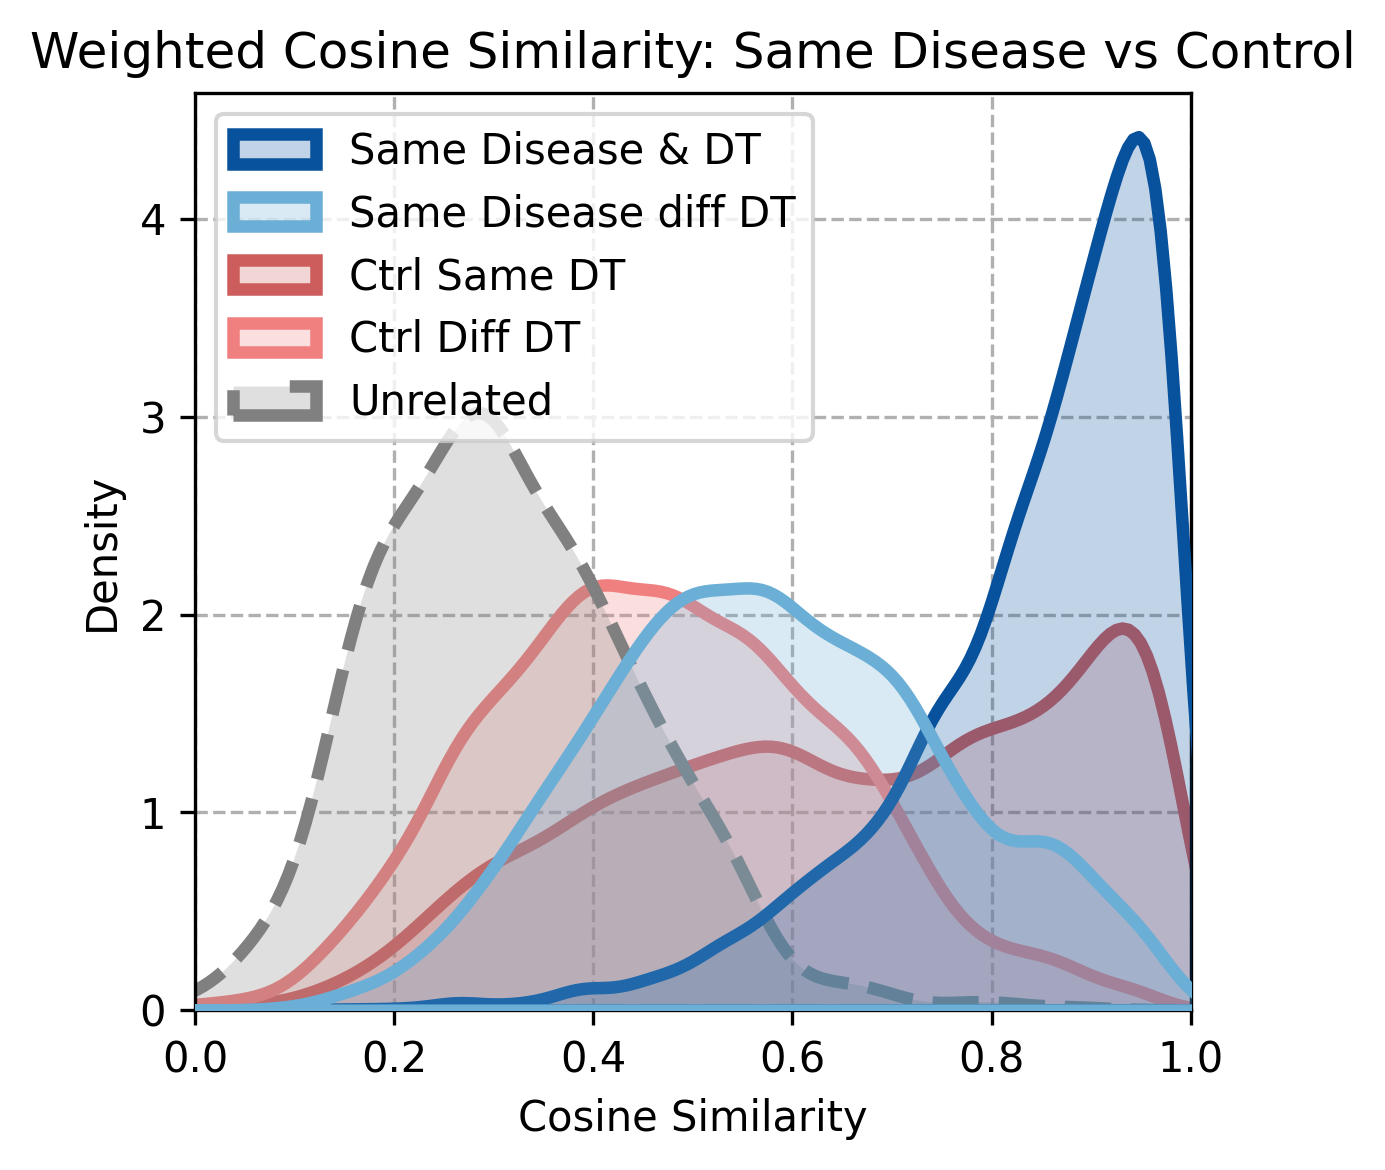

In [ ]:
# 3. Plot Similarity
# unweighted
vz.plot_kde([c_same_same, c_same_diff, c_ctrl_same, c_ctrl_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Cosine Similarity: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=None)

# weighted
vz.plot_kde([c_same_same, c_same_diff, c_ctrl_same, c_ctrl_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Weighted Cosine Similarity: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=[w_same_same, w_same_diff, w_ctrl_same, w_ctrl_diff, None])

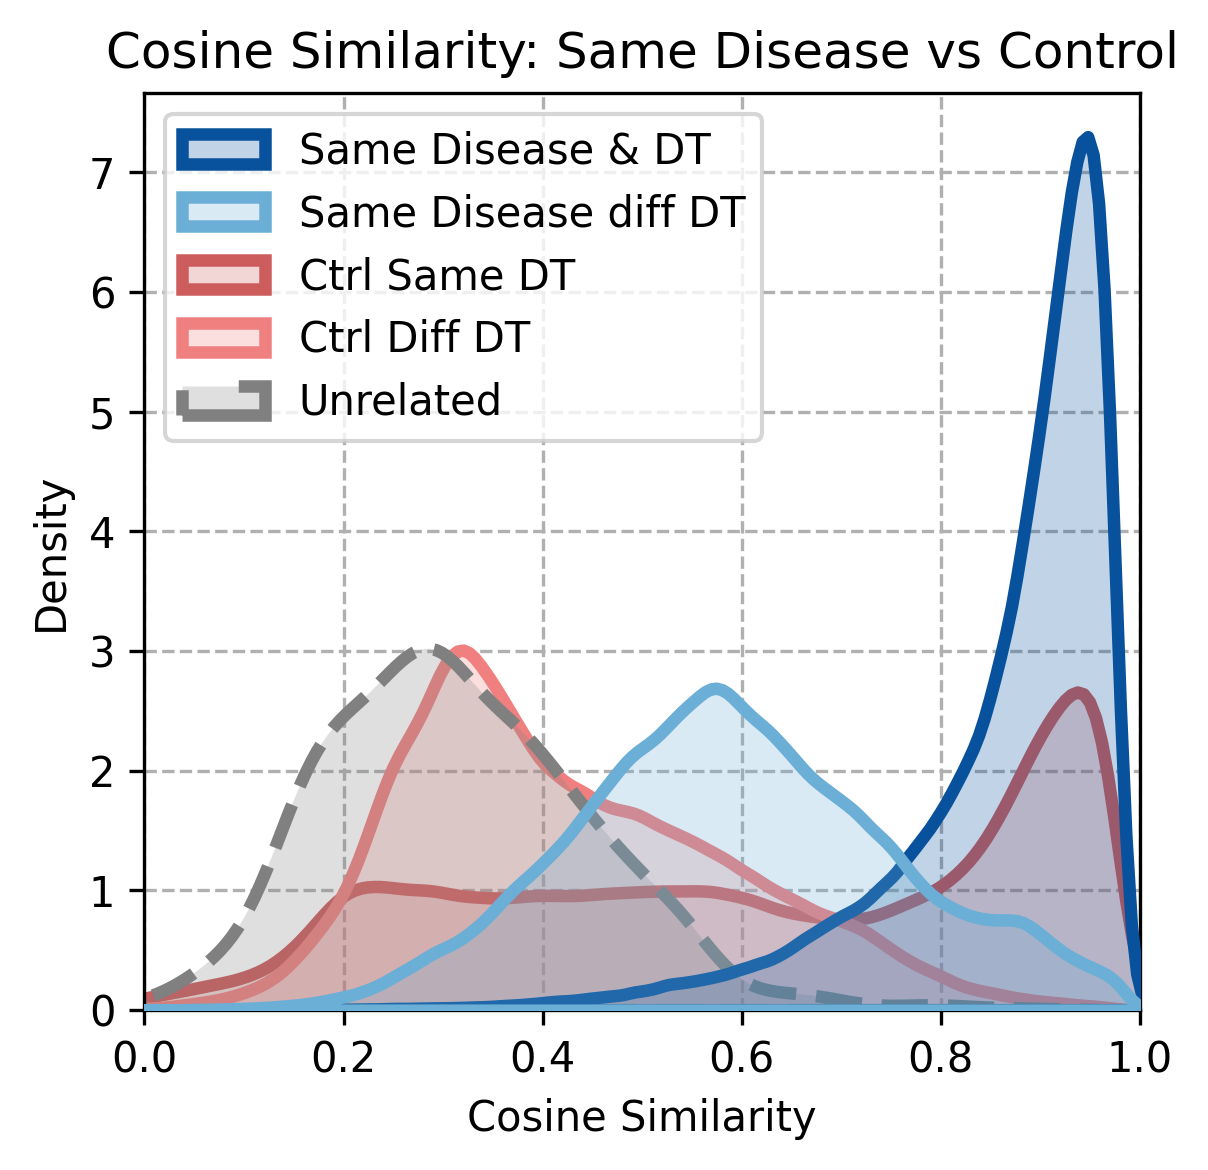

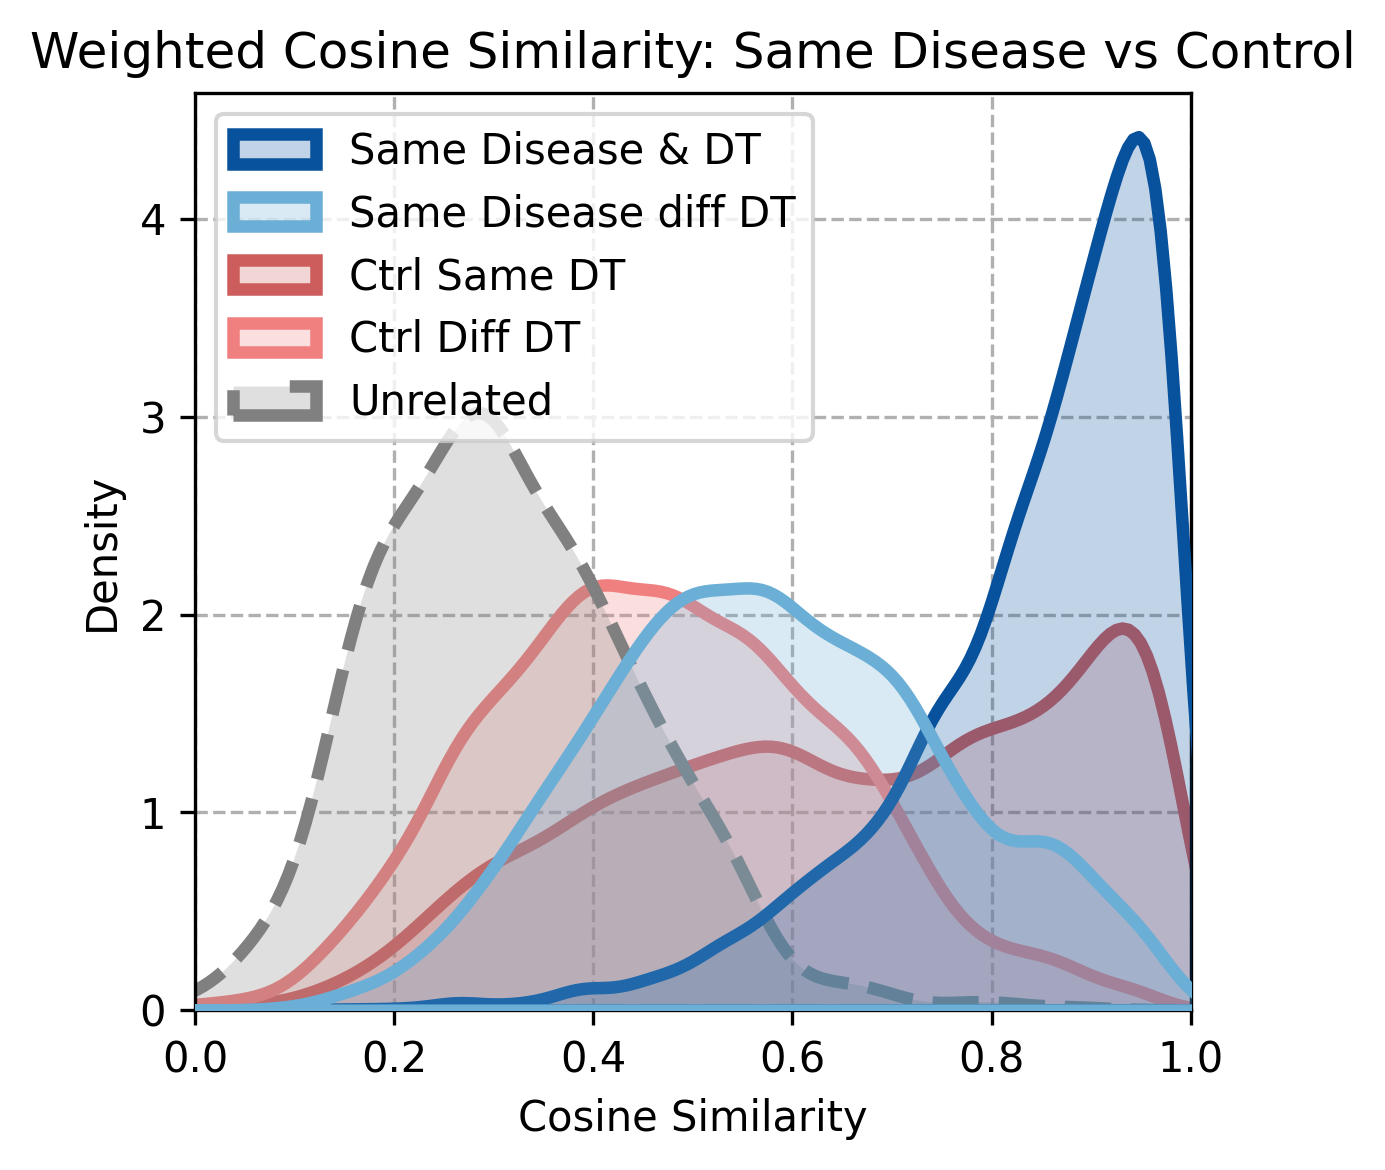

In [ ]:
# 3. Plot Similarity
# unweighted
vz.plot_kde([c_same_same, c_same_diff, c_ctrl_same, c_ctrl_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Cosine Similarity: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=None)

# weighted
vz.plot_kde([c_same_same, c_same_diff, c_ctrl_same, c_ctrl_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Weighted Cosine Similarity: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=[w_same_same, w_same_diff, w_ctrl_same, w_ctrl_diff, None])

# 3. Benchmark Disease Related Disease Similarity

100%|██████████| 7500/7500 [00:02<00:00, 3051.62it/s]


Nº of unrelated disease pairs: 67467592
[SP '0.4-0.6'] Nº of related disease pairs: 751


100%|██████████| 751/751 [00:29<00:00, 25.49it/s] 


Nº of related disease pairs for '0.4-0.6': 13417029
[SP '0.6-0.8'] Nº of related disease pairs: 169


100%|██████████| 169/169 [00:08<00:00, 19.26it/s]


Nº of related disease pairs for '0.6-0.8': 4000136
[SP '0.8-1'] Nº of related disease pairs: 58


100%|██████████| 58/58 [00:01<00:00, 40.65it/s]


Nº of related disease pairs for '0.8-1': 646768
Nº of diseases: 131


100%|██████████| 131/131 [00:06<00:00, 19.68it/s]


Nº of unrelated disease pairs: 1000


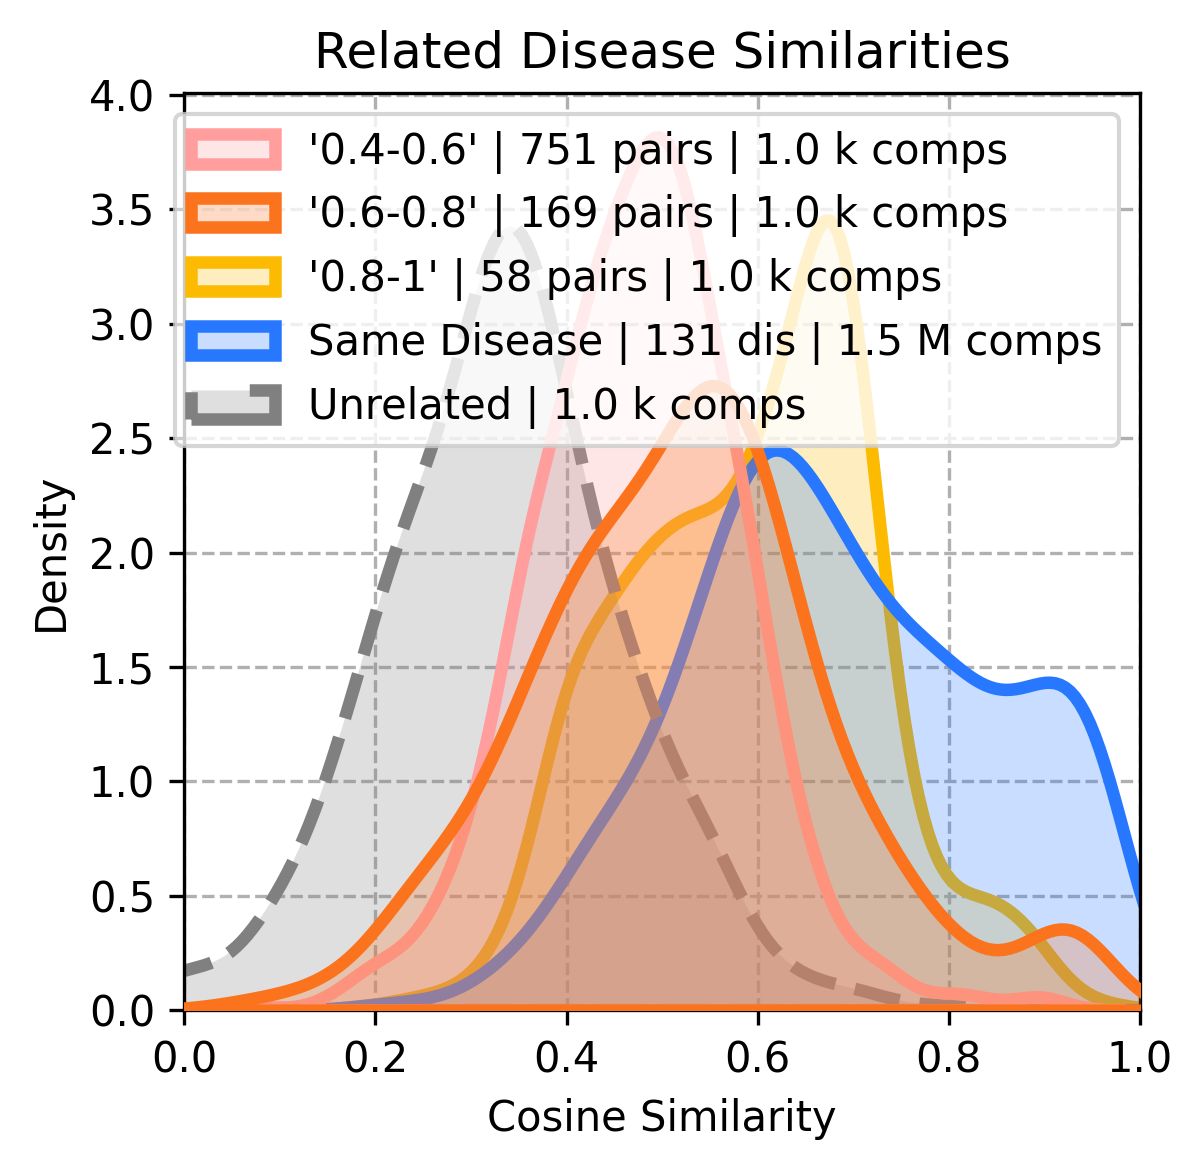

Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1510397


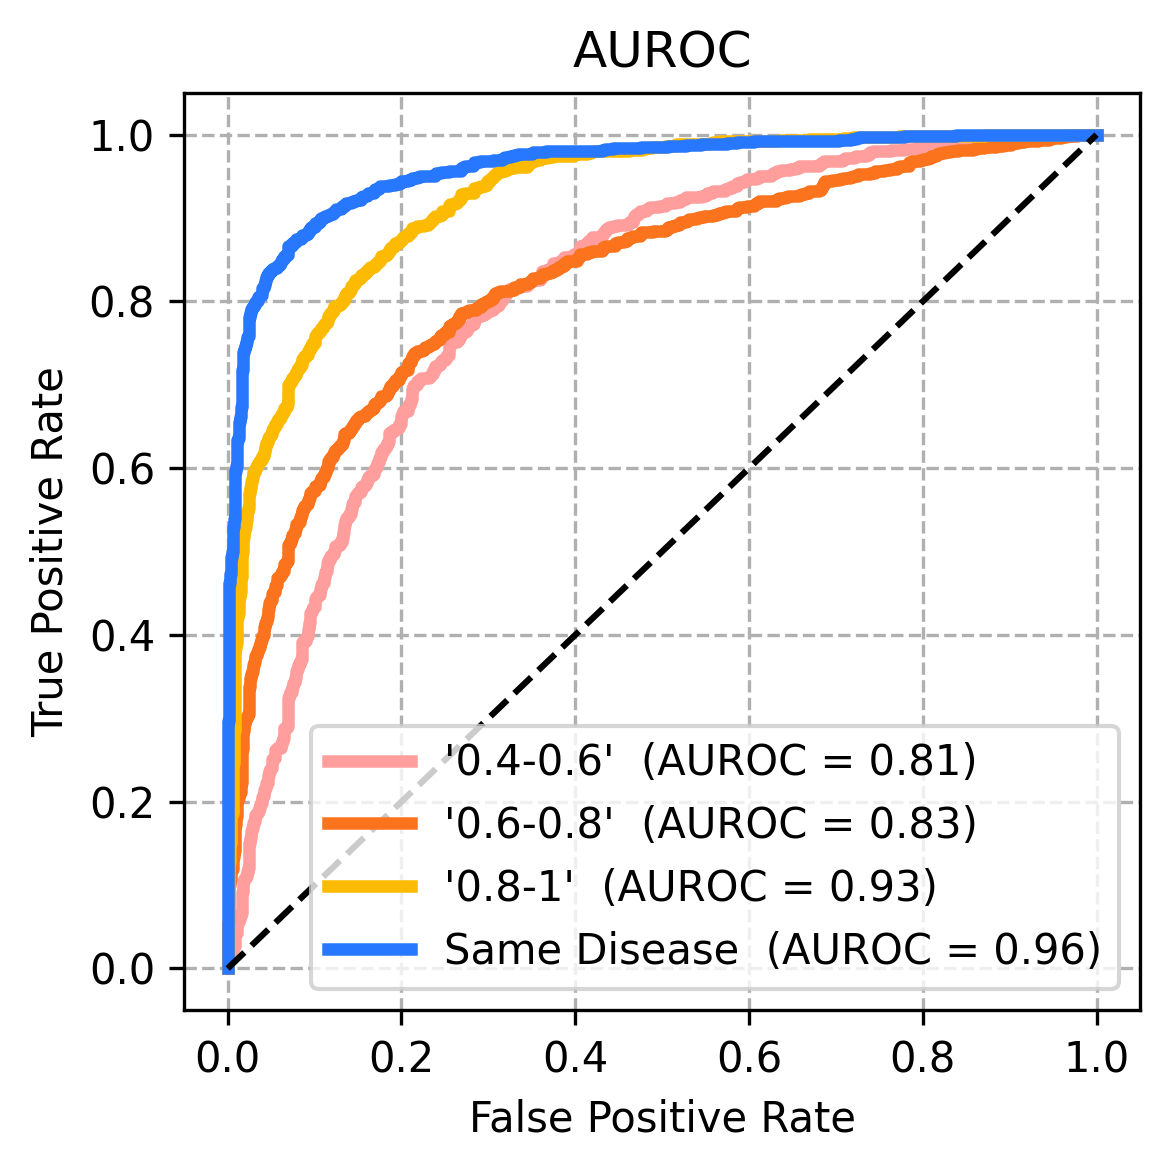

100%|██████████| 7500/7500 [00:02<00:00, 2966.99it/s]


Nº of unrelated disease pairs: 67467592
[SP 2] Nº of related disease pairs: 74


100%|██████████| 74/74 [00:01<00:00, 38.28it/s]


Nº of related disease pairs for 2: 872181
[SP 3] Nº of related disease pairs: 157


100%|██████████| 157/157 [00:07<00:00, 21.75it/s]


Nº of related disease pairs for 3: 3301286
[SP 5] Nº of related disease pairs: 151


100%|██████████| 151/151 [00:10<00:00, 15.06it/s]


Nº of related disease pairs for 5: 4570307
Nº of diseases: 131


100%|██████████| 131/131 [00:06<00:00, 19.44it/s]


Nº of unrelated disease pairs: 10000


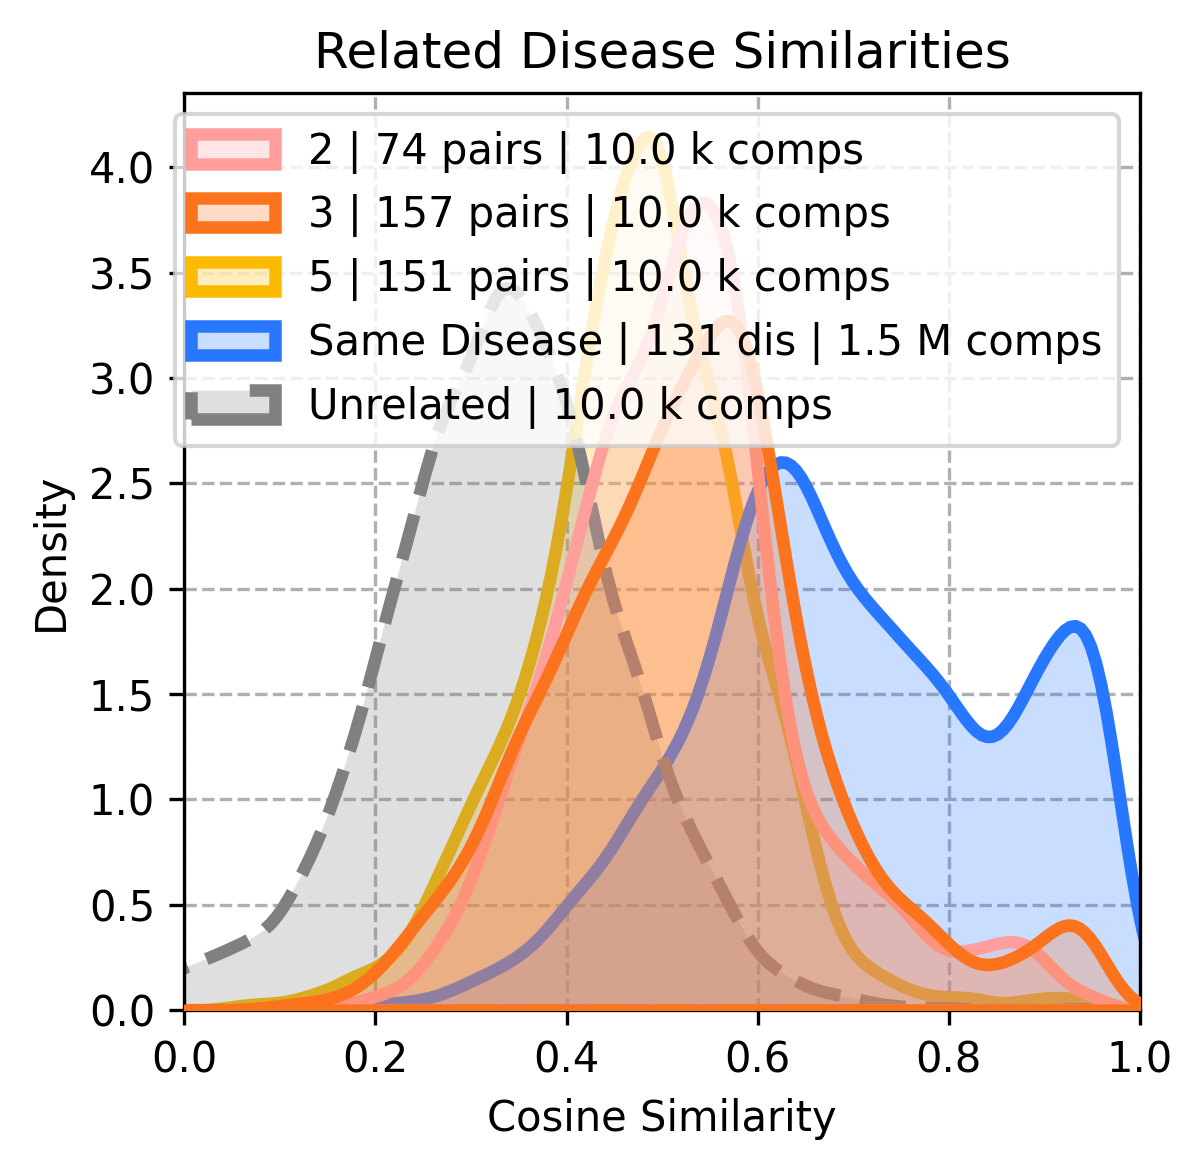

Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1510397


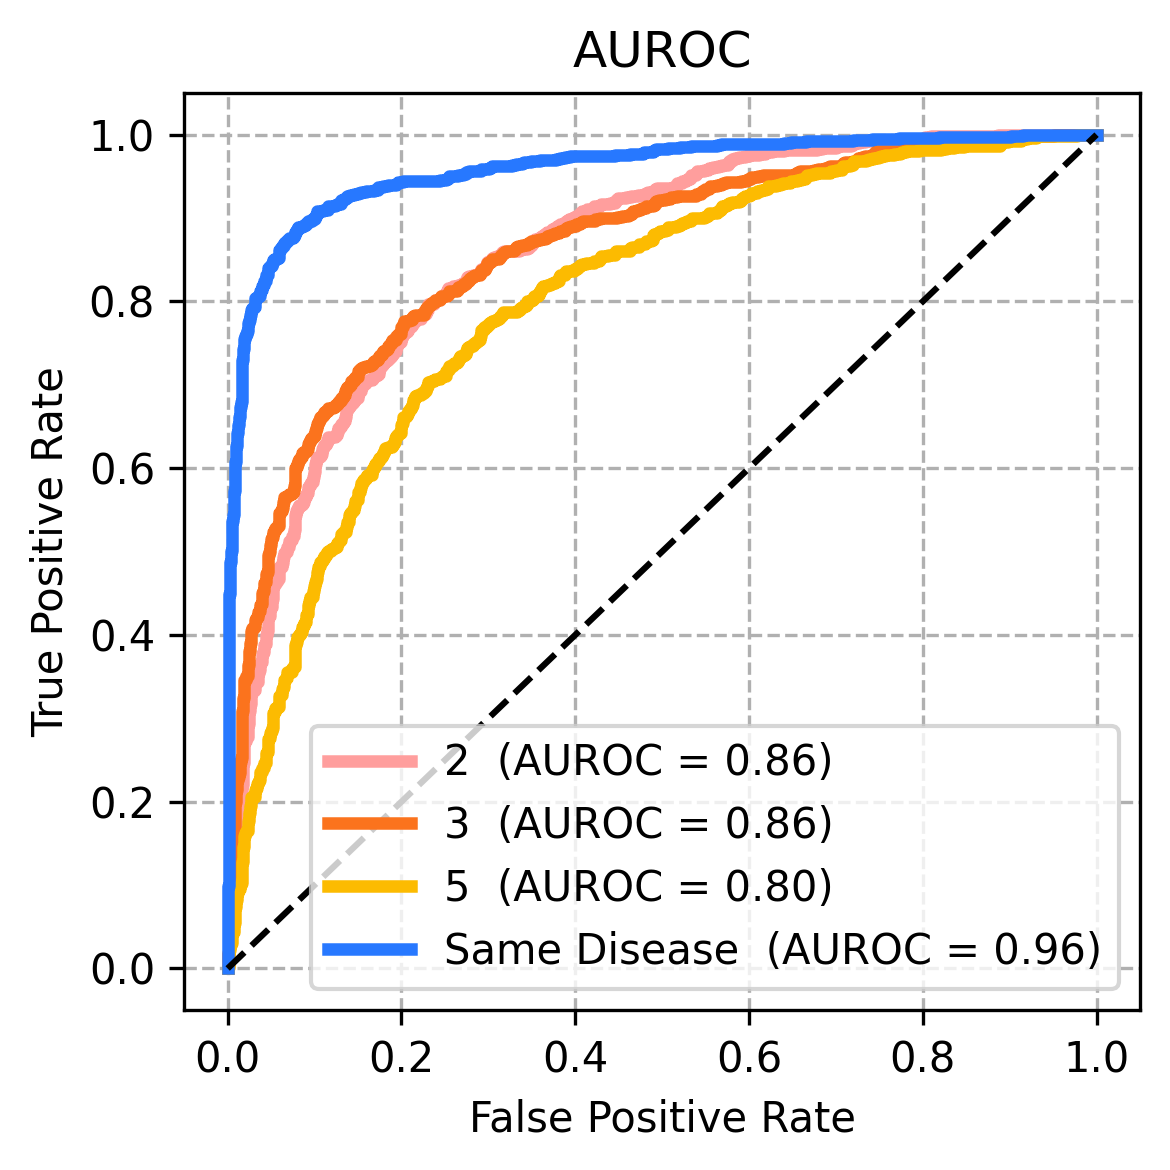

In [102]:
"""Benchmark Disease Related Disease Similarity

Structure:
    1. Imports, Variables, Functions
    2. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
import random

# variables
sample_size = 1000

# functions
def plot_roc_for_shortest_path_relatedness(
    c_matrix, do_ids, df_related, df_unrelated,  labels, colors=None, use_weights=True, sample:int=None
):
    if isinstance(labels, int):
        labels = [labels]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "grey","#2778ff", ]


    # get pairs    
    unrelated_pairs = list(df_unrelated["pair_sorted"].unique())
    unrelated_universe = get_doid_idxs_pairs(unrelated_pairs, do_ids, return_weights=False)
    print(f"Nº of unrelated disease pairs: {len(unrelated_universe)}")
    plt.figure(figsize=(4, 4), dpi=300)

    for i, label_i in enumerate(labels):

        # get all related pairs for given label / shortest_path
        _df_query = df_related.query(f"shortest_path_length == {label_i}")

        # get related pairs
        related_idxs, _w_related = get_doid_idxs_pairs(list(_df_query["pair_sorted"]), do_ids, return_weights=True)
        print(f"Nº of related disease pairs for {label_i}: {len(related_idxs)}")

        if sample:
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # get sample of unrelated pairs
        _sample_i = random.sample(range(len(unrelated_universe)), len(_c_related))
        _unrelated_sample = unrelated_universe[_sample_i]

        # get similarities between unrelated pairs
        _c_unrelated = c_matrix[_unrelated_sample[:, 0], _unrelated_sample[:, 1]]
        _w_unrelated = np.ones(len(_c_unrelated))   # do not weight - they are random - no groupings

        # ROC computation
        y_true = np.concatenate([np.ones(len(_c_related)), np.zeros(len(_c_unrelated))])
        scores = np.concatenate([_c_related, _c_unrelated])
        weights = np.concatenate([_w_related, _w_unrelated])

        if use_weights:
            fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=weights)
        else:
            fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{label_i} (AUROC = {roc_auc:.2f})",
            color=colors[i],
            linewidth=3,
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC")
    plt.legend()
    plt.tight_layout()
    plt.grid(linestyle="--", zorder=-1)
    plt.show()

def get_doid_idxs_pairs(pairs:List[Tuple], do_ids:List, datasets:List=None, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    universe_pairs = list()
    l_weights = list()  # label weights
    for doid_a, doid_b in tqdm(pairs):
        
        # retrieve disease idxs pairs
        idx1 = np.where(do_ids == doid_a)[0]
        idx2 = np.where(do_ids == doid_b)[0]

        # compute idx combinations
        idx_pairs = list(itertools.product(idx1, idx2))

        # if ONLY take into account diseases DIFFERENT datasets
        if datasets is not None:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets[p[0]] != datasets[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([f"{doid_a} - {doid_b}"] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:
        return universe_pairs

def get_doid_idxs_single(do_ids:List, datasets:List=None, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    uniq_do_ids = list(set(do_ids))
    uniq_do_ids = [c for c in uniq_do_ids if c != "Control"]

    print(f"Nº of diseases: {len(uniq_do_ids)}")

    universe_pairs = list()
    l_weights = list()  # label weights
    for doid_i in tqdm(uniq_do_ids):

        # retrieve disease idxs pairs
        idx1 = np.where(do_ids == doid_i)[0]

        # compute idx combinations
        idx_pairs = list(itertools.combinations(idx1, 2))

        # if ONLY take into account diseases DIFFERENT datasets
        if datasets is not None:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets[p[0]] != datasets[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([doid_i] * len(idx_pairs))

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:
        return universe_pairs

def plot_roc(
    Y_pos:List[np.array], Y_neg:np.array, colors:List[str], labels:List[str],w_pos:List[np.array]=None, sample:int=np.inf
):
    from sklearn.metrics import roc_curve, auc
    # prep negatives
    if len(Y_neg) > sample:
        _sample_i = random.sample(range(len(Y_neg)), sample)
        Y_neg = Y_neg[_sample_i]    


    plt.figure(figsize=(4, 4), dpi=300)
    # get pairs    
    for i in range(len(Y_pos)):
        Y_pos_i = Y_pos[i]
        w_pos_i = w_pos[i] if w_pos else None
        print(f"Nº of positive disease pairs: {len(Y_pos_i)}")
        
        if len(Y_pos_i) > sample:
            _sample_i = random.sample(range(len(Y_pos_i)), sample)
            Y_pos_i = Y_pos_i[_sample_i]
            w_pos_i = w_pos_i[_sample_i] if w_pos else None    
        
        # ROC computation
        y_true = np.concatenate([np.ones(len(Y_pos_i)), np.zeros(len(Y_neg))])
        scores = np.concatenate([Y_pos_i, Y_neg])
        weights = np.concatenate([w_pos_i, np.ones(len(Y_neg))]) if w_pos_i is not None else None

        fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=weights)
        roc_auc = auc(fpr, tpr)
        plt.plot(
            fpr,
            tpr,
            label=labels[i] + f" (AUROC = {roc_auc:.2f})",
            color=colors[i],
            linewidth=3,
        )
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC")
    plt.legend()
    plt.tight_layout()
    plt.grid(linestyle="--", zorder=-1)
    plt.show()


def _convert_labels_to_weights(labels: List[str]) -> List[float]:
    """Convert labels to weights"""
    counts = Counter(labels)
    w = np.array([1.0 / counts[d] for d in labels], dtype=float)
    w /= w.sum()                               # normalize to sum to 1
    return w


def get_bins(vals, bins):
    """
    Get the bin for each value in vals based on the provided bins.
    """
    bin_list = list()
    for val in vals:
        for i in range(len(bins) - 1):
            if bins[i] <= val < bins[i + 1]:
                bin_list.append((f"{bins[i]}-{bins[i + 1]}"))
                break
    return bin_list


def _convert_labels_to_weights(labels: List[str]) -> List[float]:
    """Convert labels to weights"""
    counts = Counter(labels)
    w = np.array([1.0 / counts[d] for d in labels], dtype=float)
    w /= w.sum()                               # normalize to sum to 1
    return w

def get_related_dis_sim(
    c_matrix, do_ids, df_related, df_unrelated, labels,datasets:List=None, sample:int=None
):
    from matplotlib.ticker import EngFormatter
    fmt = EngFormatter(places=1)
   
    # get pairs    
    unrelated_pairs = list(df_unrelated["pair_sorted"].unique())
    unrelated_universe = get_doid_idxs_pairs(unrelated_pairs, do_ids, return_weights=False)
    print(f"Nº of unrelated disease pairs: {len(unrelated_universe)}")
    
    c_all = list()
    w_all = list()
    l_all = list()
    _sample_sizes = list()
    for i, label_i in enumerate(labels):
        _df_related = df_related.query(f"shortest_path_length == {label_i}")
        print(f"[SP {label_i}] Nº of related disease pairs: {len(_df_related)}")

        # get related pairs
        related_idxs, _l_related = get_doid_idxs_pairs(list(_df_related["pair_sorted"]), do_ids, datasets, return_weights=True)
        print(f"Nº of related disease pairs for {label_i}: {len(related_idxs)}")

        # convert label to weights - all pairs add to 1
        _w_related = _convert_labels_to_weights(_l_related)

        if sample:
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        # retrieve similarities
        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # append values
        c_all.append(_c_related)
        w_all.append(_w_related)
        _sample_sizes.append(len(_c_related))

        # append labels
        l_all.append(f"{label_i} | {len(_df_related)} pairs | {fmt(len(_c_related))} comps",)


    # get sample of SAME DISEASE
    same_idxs, _l_same = get_doid_idxs_single(do_ids, datasets, return_weights=True)
    _w_same = _convert_labels_to_weights(_l_same)
    _c_same = c_matrix[same_idxs[:, 0], same_idxs[:, 1]]
    c_all.append(_c_same)
    w_all.append(_w_same)
    l_all.append(f"Same Disease | {len(set(do_ids)-set(["Control"]))} dis | {fmt(len(_c_same))} comps")

    # get sample of unrelated pairs
    _sample_i = random.sample(range(len(unrelated_universe)), max(_sample_sizes))
    _unrelated_sample = unrelated_universe[_sample_i]
    print(f"Nº of unrelated disease pairs: {len(_unrelated_sample)}")
    
    _c_unrelated = c_matrix[_unrelated_sample[:, 0], _unrelated_sample[:, 1]]
    _w_unrelated = np.ones(len(_c_unrelated))   # do not weight - they are random - no groupings
    c_all.append(_c_unrelated)
    w_all.append(_w_unrelated)
    l_all.append(f"Unrelated | {fmt(len(_c_unrelated))} comps")

    return c_all, w_all, l_all


# 2. Plot Similarity

# Plot similarity based on semantic similarity
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# bin data based on similarity
_bins = get_bins(do_df_ic_query["lin"].values,[0,0.2,0.4,0.6,0.8,1])
_bin_labels = ["'0.4-0.6'","'0.6-0.8'","'0.8-1'",]

# add new label to dataframe
df_related = df_related.copy()
df_related["shortest_path_length"] = _bins

# get DO IDs
do_ids = adata_train.obs["do_id"].values
datasets = adata_train.obs["dataset"].values



colors = ["#ff9e9d", "#fb731d", "#fcbb01","#2778ff","grey"]

c_all, w_all, l_all = get_related_dis_sim(
    c_matrix_train, do_ids, df_related, df_unrelated, datasets=datasets, labels=_bin_labels, sample=sample_size,
)

vz.plot_kde(c_all, labels=l_all, colors=colors, title="Related Disease Similarities", metric="Cosine", weights=None, sample=sample_size)

_lab = [x.split("|")[0] for x in l_all[:-1]]
plot_roc(c_all[:-1], c_all[-1], labels=_lab, colors=colors, w_pos=None,sample=1000)



# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# define labels
labels = [2, 3, 5]
sample_size = 10000
c_all, w_all, l_all = get_related_dis_sim(
    c_matrix_train, do_ids, df_related, df_unrelated, datasets=datasets, labels=labels, sample=sample_size,
)


vz.plot_kde(c_all, labels=l_all, colors=colors, title="Related Disease Similarities", metric="Cosine", weights=None, sample=sample_size)
_lab = [x.split("|")[0] for x in l_all[:-1]]
plot_roc(c_all[:-1], c_all[-1], labels=_lab, colors=colors, w_pos=None,sample=1000)


100%|██████████| 7500/7500 [00:02<00:00, 2669.99it/s]


Nº of unrelated disease pairs: 77654643
[SP '0.4-0.6'] Nº of related disease pairs: 751


100%|██████████| 751/751 [00:32<00:00, 23.21it/s] 


Nº of related disease pairs for '0.4-0.6': 14930415
[SP '0.6-0.8'] Nº of related disease pairs: 169


100%|██████████| 169/169 [00:08<00:00, 21.03it/s]


Nº of related disease pairs for '0.6-0.8': 3700861
[SP '0.8-1'] Nº of related disease pairs: 58


100%|██████████| 58/58 [00:01<00:00, 34.46it/s]


Nº of related disease pairs for '0.8-1': 768343
Nº of diseases: 131


100%|██████████| 131/131 [00:06<00:00, 20.22it/s]


Nº of unrelated disease pairs: 1000


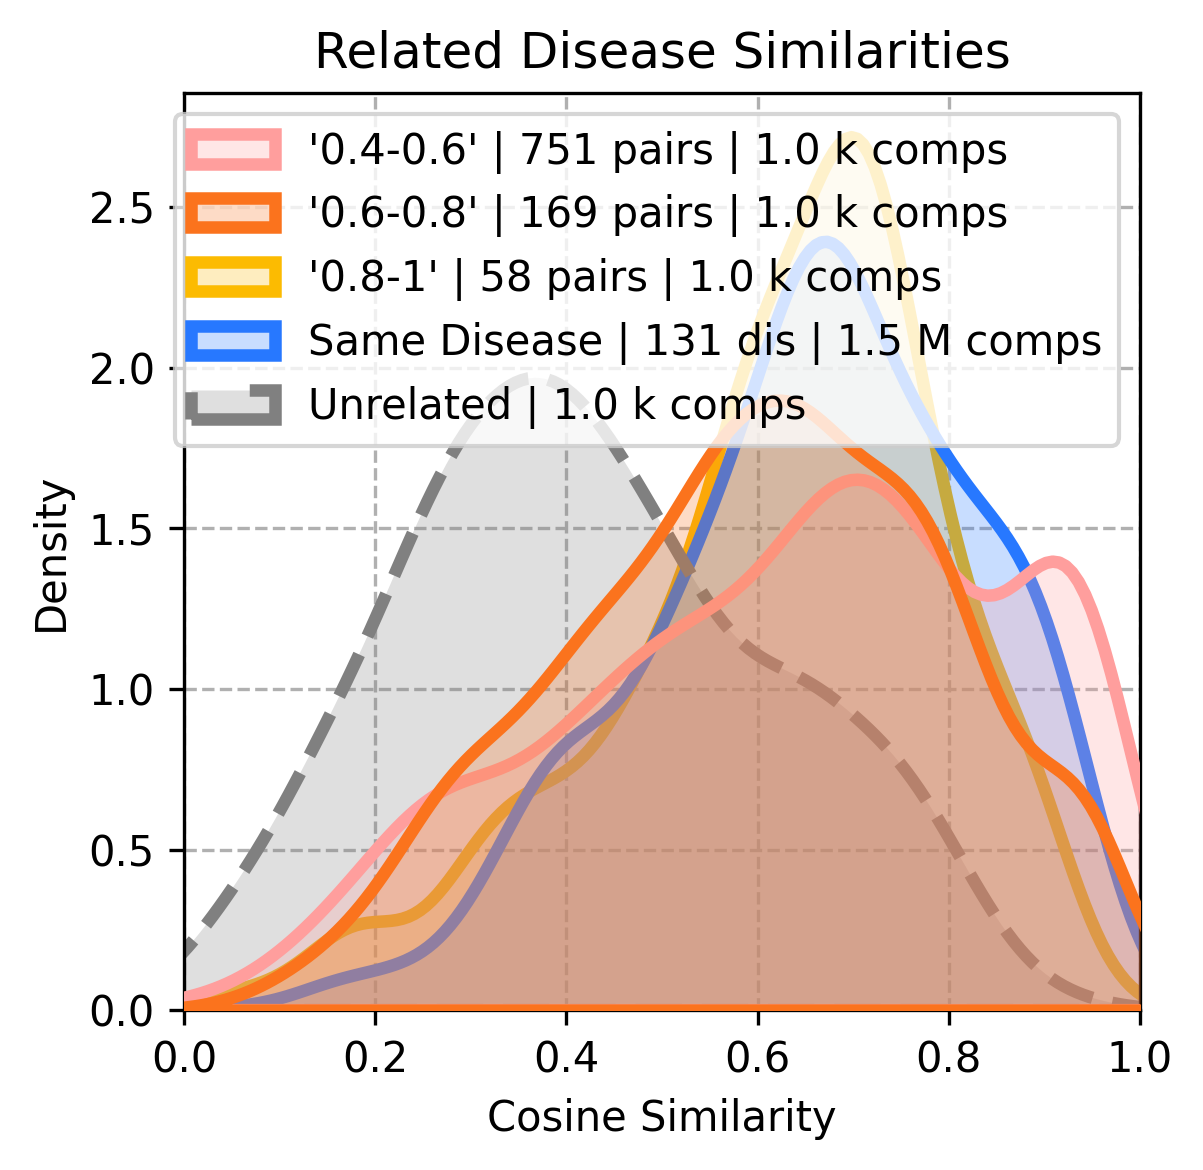

Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1459165


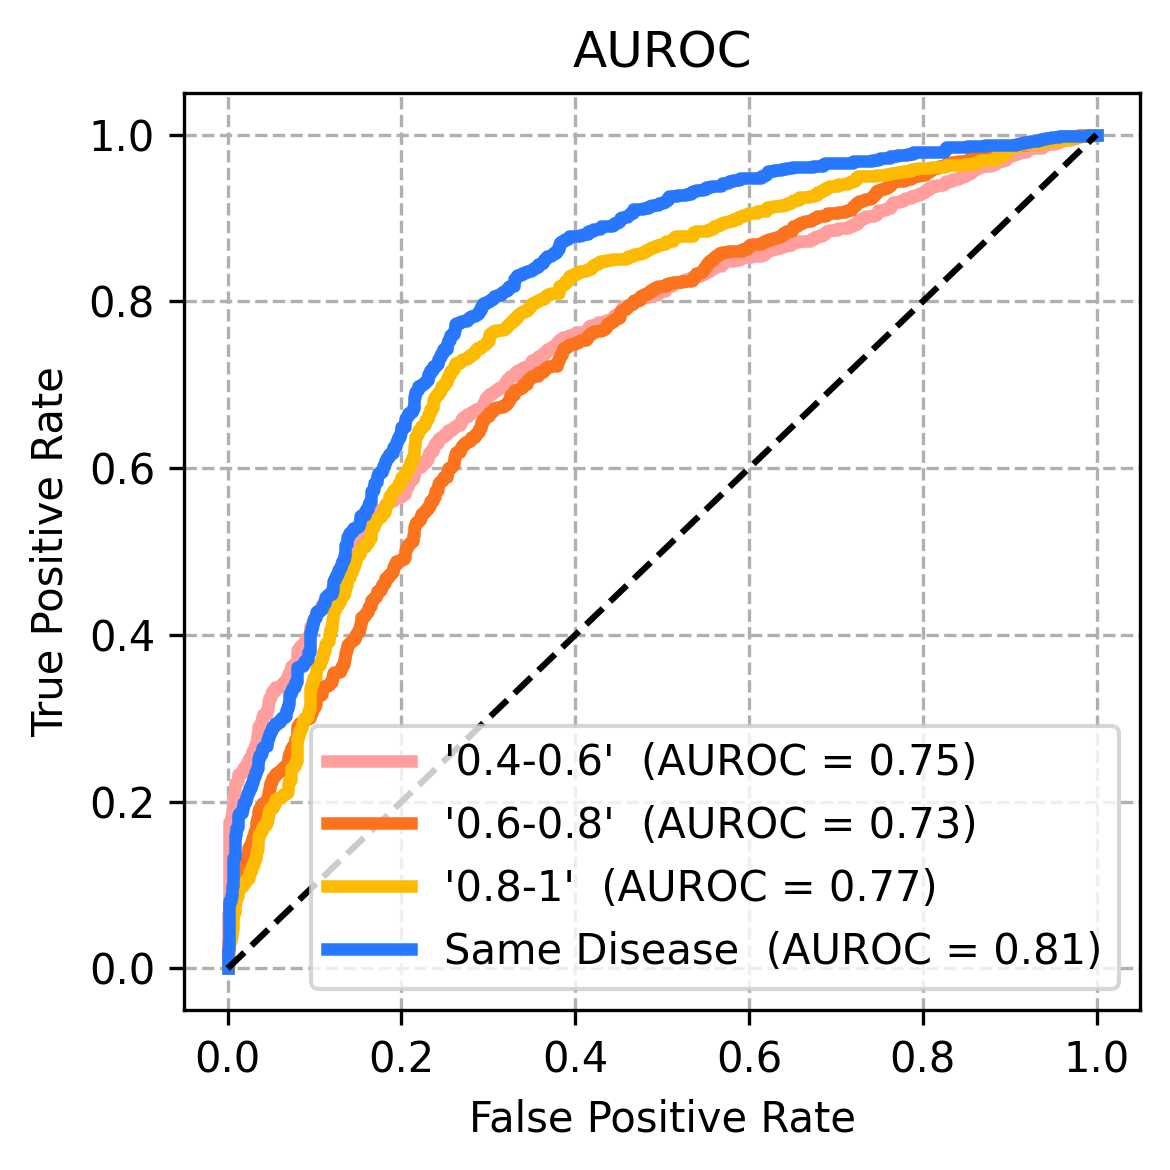

100%|██████████| 7500/7500 [00:02<00:00, 2692.11it/s]


Nº of unrelated disease pairs: 77654643
[SP 2] Nº of related disease pairs: 74


100%|██████████| 74/74 [00:01<00:00, 55.98it/s]


Nº of related disease pairs for 2: 604136
[SP 3] Nº of related disease pairs: 157


100%|██████████| 157/157 [00:06<00:00, 25.43it/s]


Nº of related disease pairs for 3: 2832610
[SP 5] Nº of related disease pairs: 151


100%|██████████| 151/151 [00:09<00:00, 15.51it/s]


Nº of related disease pairs for 5: 4453964
Nº of diseases: 131


100%|██████████| 131/131 [00:06<00:00, 20.11it/s]


Nº of unrelated disease pairs: 10000


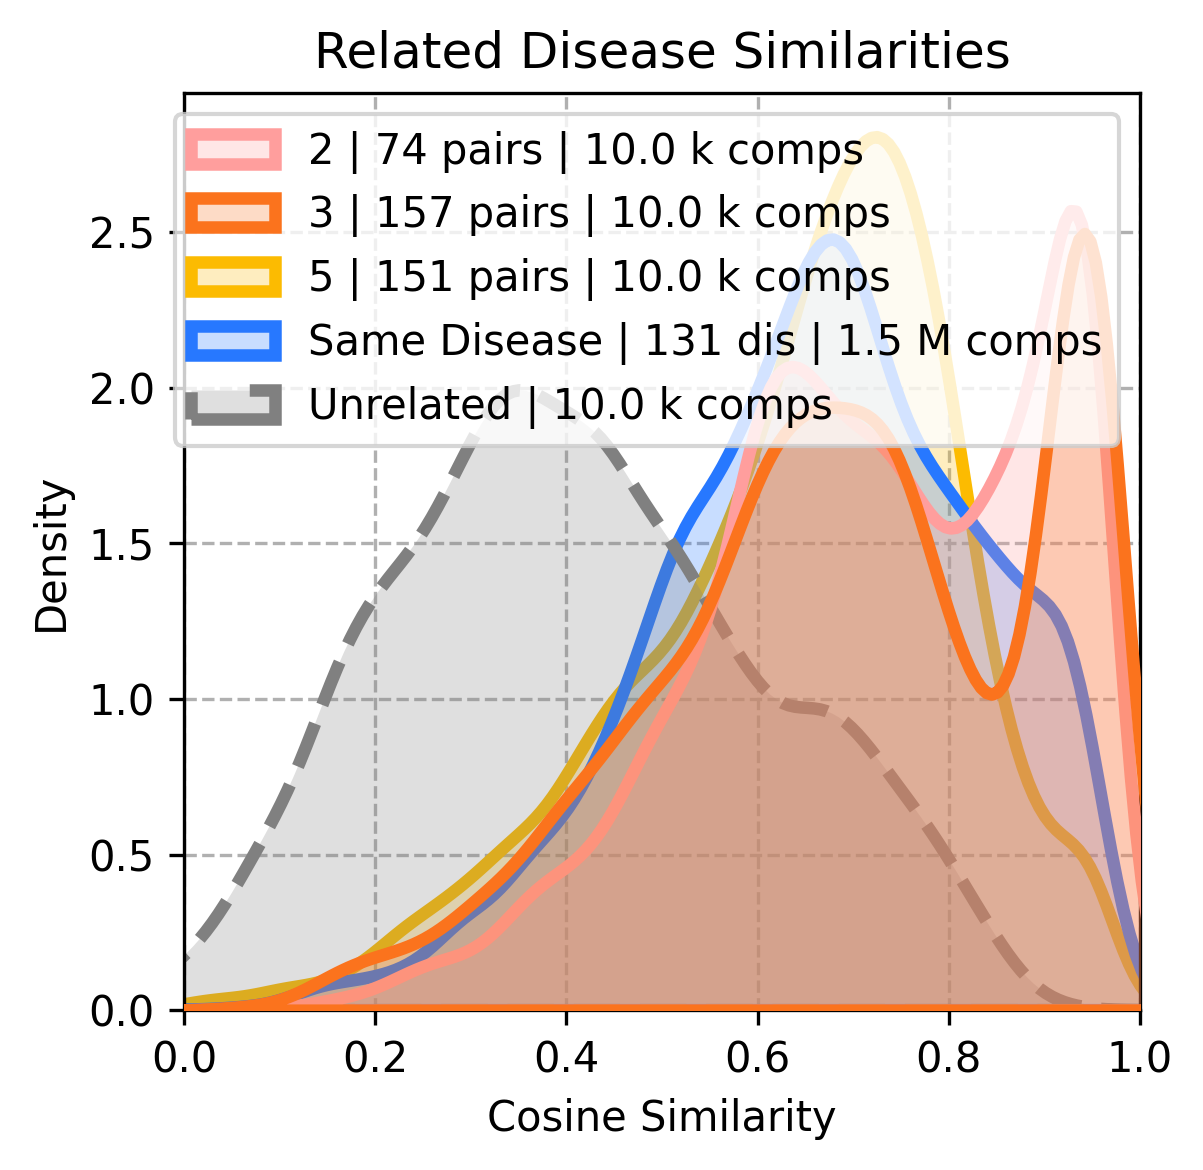

Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1459165


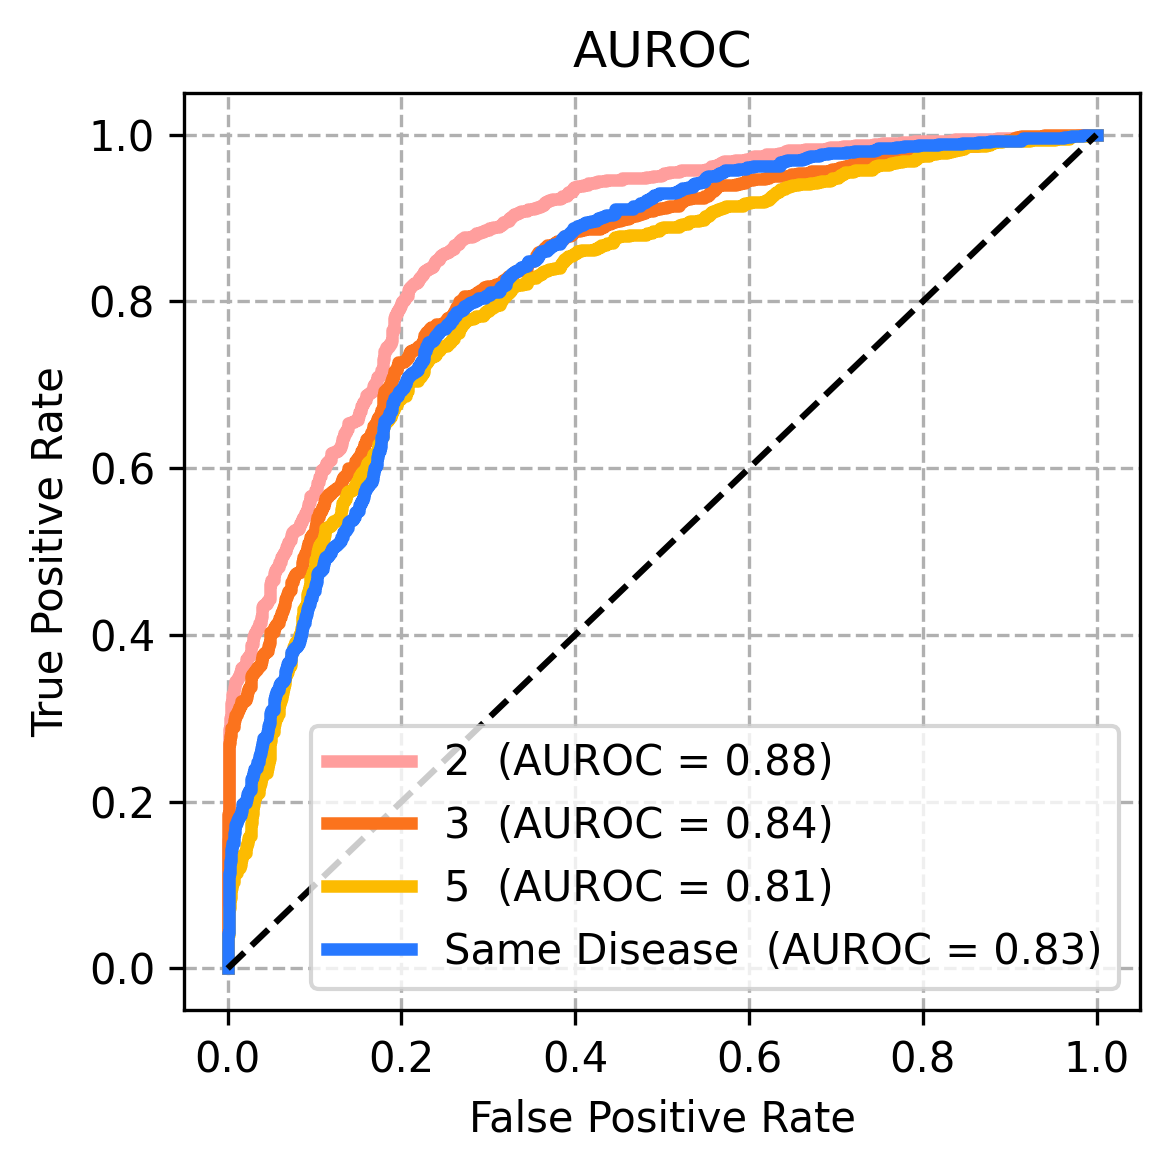

In [93]:
import importlib
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

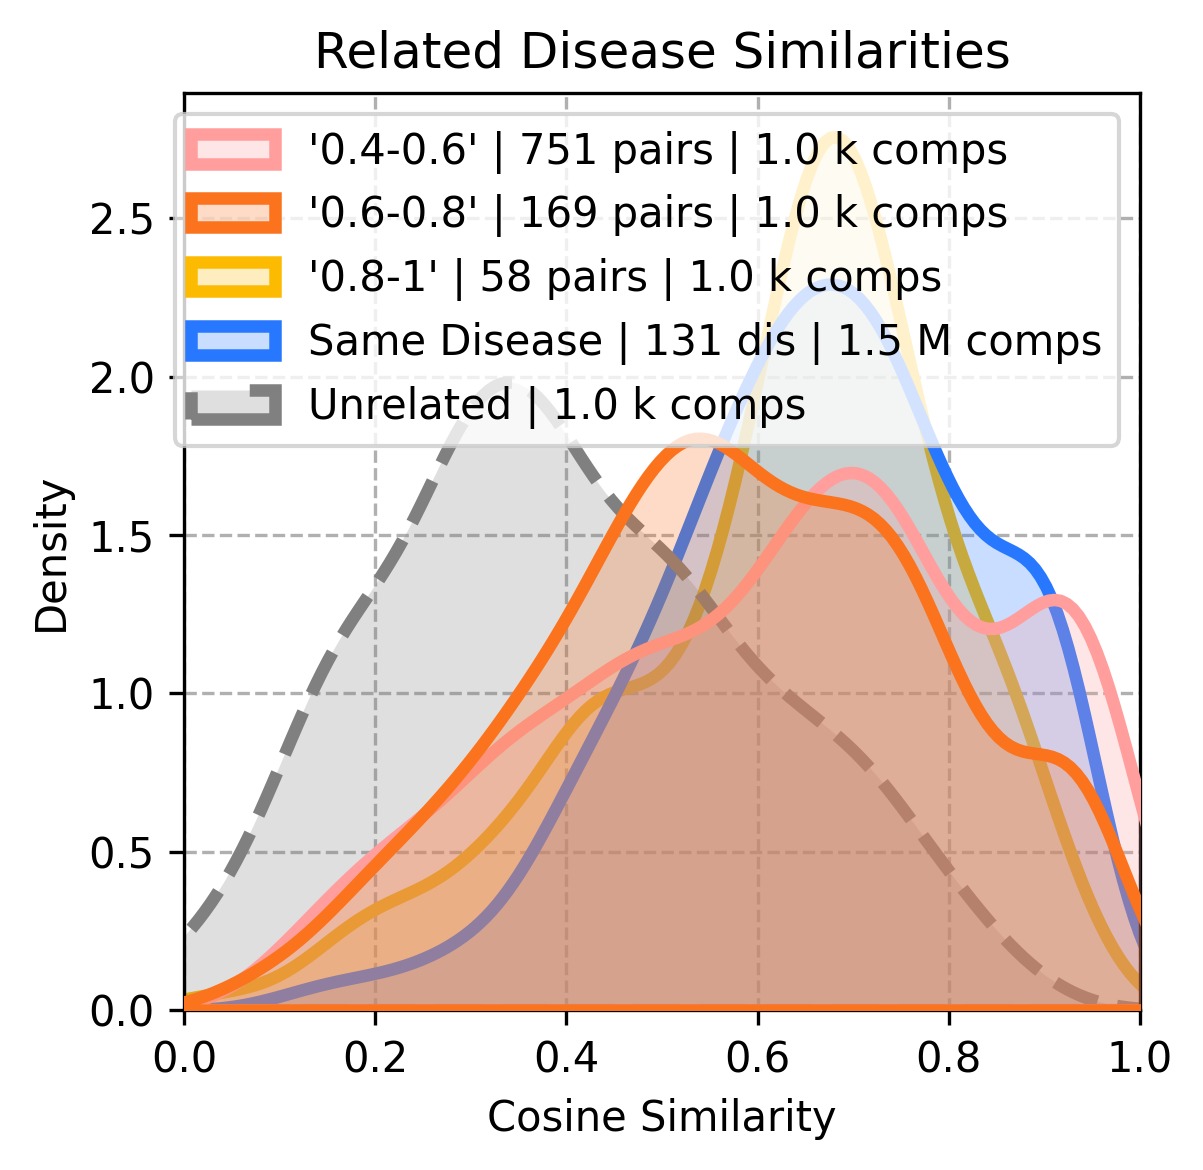

In [94]:
vz.plot_kde(c_all, labels=l_all, colors=colors, title="Related Disease Similarities", metric="Cosine", weights=None, sample=sample_size)


In [ ]:

# weighted
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, do_ids, df_related, df_unrelated, labels=_bin_labels[::-1], sample=sample_size, use_weights=True
)
plot_roc_for_shortest_path_relatedness(c_matrix_train, do_ids, df_related, df_unrelated, labels=_bin_labels[::-1], colors=None, use_weights=True, sample=sample_size)

# unweighted
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, do_ids, df_related, df_unrelated, datasets=datasets, labels=_bin_labels[::-1], sample=sample_size, use_weights=False
)
plot_roc_for_shortest_path_relatedness(c_matrix_train, do_ids, df_related, df_unrelated, labels=_bin_labels[::-1], colors=None, use_weights=False,  sample=sample_size
)


# Plot similarity based on shortest path distance
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# get DO IDs
do_ids = adata_train.obs["do_id"].values

# weighted
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, do_ids, df_related, df_unrelated, labels=[2, 3, 5], sample=sample_size, use_weights=True
)
plot_roc_for_shortest_path_relatedness(c_matrix_train, do_ids, df_related, df_unrelated, labels=[2, 3, 5], colors=None, use_weights=True, sample=sample_size)

# unweighted
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, do_ids, df_related, df_unrelated, labels=[2, 3, 5], sample=sample_size, use_weights=False
)
plot_roc_for_shortest_path_relatedness(c_matrix_train, do_ids, df_related, df_unrelated, labels=[2, 3, 5], colors=None, use_weights=False, sample=sample_size
)




# 4. tSNE Embeddiding plots

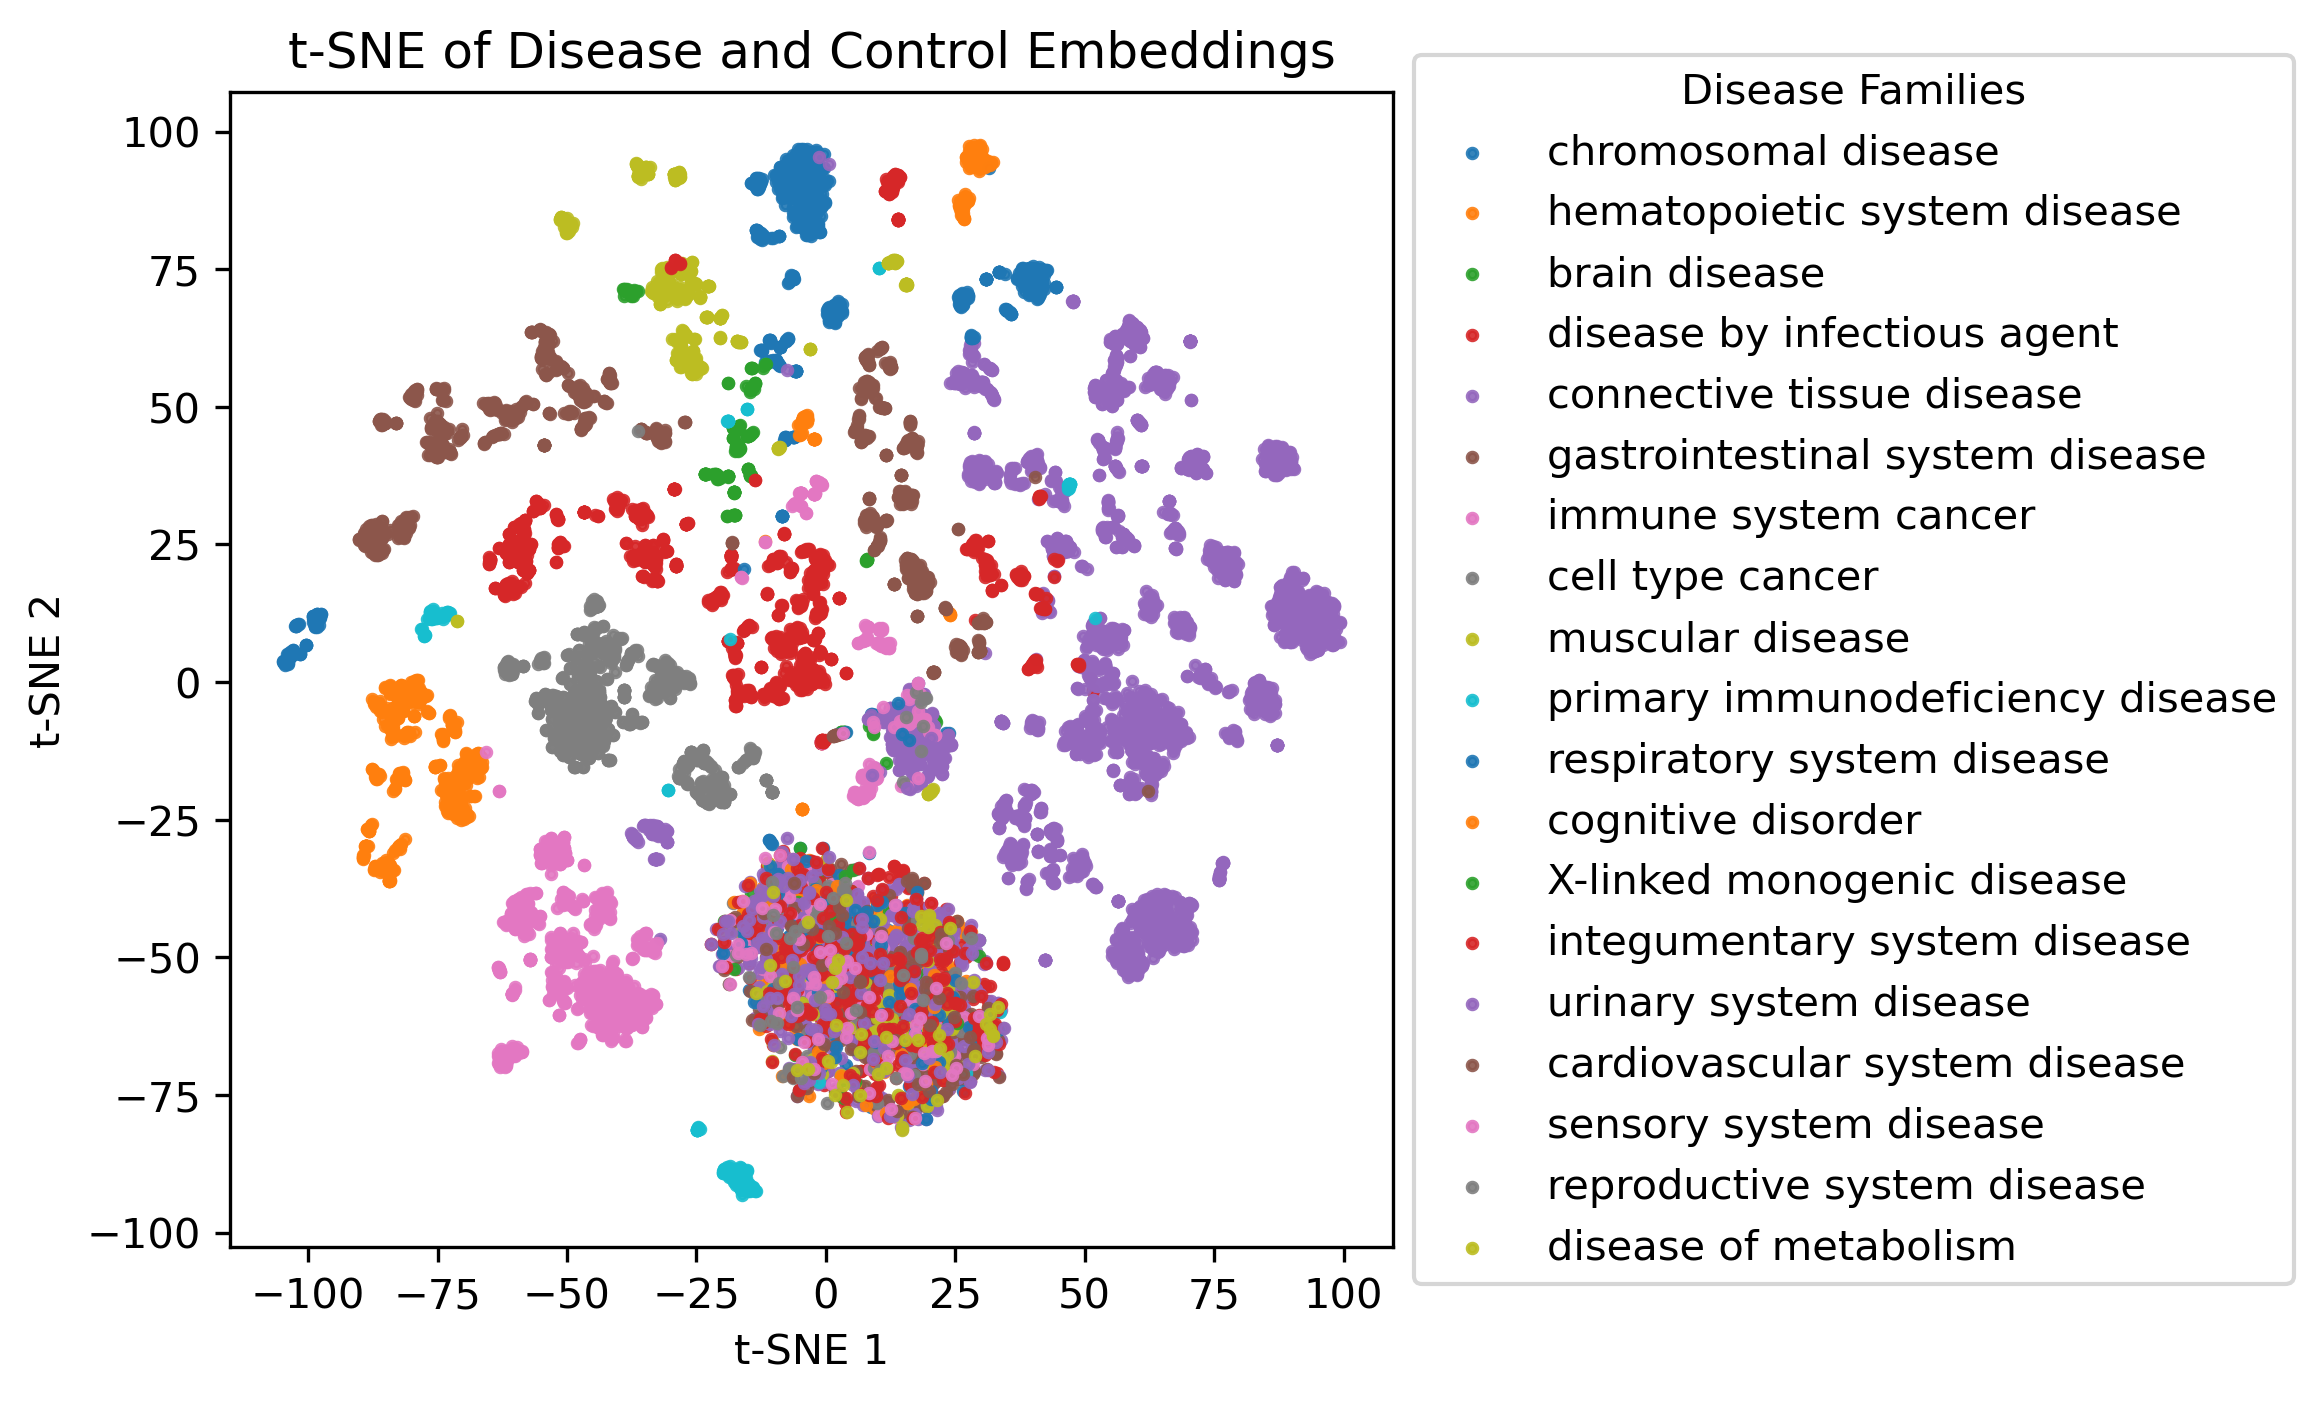

In [ ]:
# t-SNE
from sklearn.manifold import TSNE

# Lets color by disease families
_d_masks = list()
for i in adata_train.obs["do_id"].unique():
    _d_masks.append((i, np.array((adata_train.obs["do_id"] == i) & (adata_train.obs["is_control"] == "D"))))

# let's run t-SN
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(embeddings_train)

# scatter plot 
plt.figure(figsize=(5, 5), dpi=300)
for i in range(len(_d_masks)):
    _doid, _d_mask = _d_masks[i]
    plt.scatter(
        X_embedded[_d_mask][:, 0], X_embedded[_d_mask][:, 1], label=doid_to_term.get(_doid), alpha=0.9, s=5
    )
plt.title("t-SNE of Disease and Control Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Disease Families")

In [ ]:

def plot_kde_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "#2778ff", "#d6f3ff"]  # default palette

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    print(len(unrelated_keys), "unrelated disease pairs")
    do_ids = adata_obs["do_id"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        print(f"[SP {sp_val}] Nº of related disease pairs: {len(_df_query)}")

        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related) / len(_c_related)

        sns.kdeplot(
            x=_c_related,
            weights=_w_related,
            label=f"{sp_val} (n={len(_c_related)})",
            fill=True,
            color=colors[i % len(colors)],
            zorder=3,
            linewidth=3,
        )

    # Add shared random baseline
    n_needed = len(_c_related) // 10
    print("n_needed", n_needed)
    print("len(c_relate)", len(_c_related))

    rand_pairs = set()
    while len(rand_pairs) < n_needed:
        a, b = np.random.choice(len(do_ids), 2, replace=False)
        do1, do2 = do_ids[a], do_ids[b]
        if do1 == do2:
            continue
        if tuple(sorted([do1, do2])) in unrelated_keys:
            continue
        rand_pairs.add((a, b))

    rand_pairs = np.array(list(rand_pairs))
    print(len(rand_pairs))
    _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
    sns.kdeplot(_c_rand, label="Unrelated", fill=True, color="gray", linewidth=3,  zorder=2)

    plt.title("Cosine Similarity: Related Diseases")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")

    # plot legend title
    plt.legend(title="DO disease distance")

    plt.tight_layout()
    plt.xlim(0, 1)
    plt.grid(zorder=-3, linestyle="--")
    plt.show()

def plot_roc_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None, weights_bool=True
):
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "grey","#2778ff", ]

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    do_ids = adata_obs["do_id"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related)

        # Negative sampling
        rand_pairs = set()
        while len(rand_pairs) < len(_c_related):
            a, b = np.random.choice(len(do_ids), 2, replace=False)
            do1, do2 = do_ids[a], do_ids[b]
            if do1 == do2:
                continue
            if tuple(sorted([do1, do2])) in unrelated_keys:
                continue
            rand_pairs.add((a, b))
        rand_pairs = np.array(list(rand_pairs))
        _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
        _w_rand = np.ones(len(_c_rand))

        # ROC computation
        y_true = np.concatenate([np.ones(len(_c_related)), np.zeros(len(_c_rand))])
        scores = np.concatenate([_c_related, _c_rand])
        weights = np.concatenate([_w_related, _w_rand])

        if weights_bool:
            fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=weights)
        else:
            fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{sp_val} (AUROC = {roc_auc:.2f})",
            color=colors[i],
            linewidth=3,
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC")
    plt.legend()
    plt.tight_layout()
    plt.grid(linestyle="--", zorder=-1)
    plt.show()

